# Notebook 01 — Panorama dos Métodos Avançados em RL

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Bibliotecas:** numpy, matplotlib  
**Ambiente:** nenhum (notebook conceitual com visualizações)

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 01 — Panorama dos Métodos Avançados |
| **Seções** | 4.1–4.8 (introdução) |
| **Tempo de leitura** | ~15 min |
| **Tempo de execução** | ~2 min |

**Pré-requisitos:** Aulas 02 e 03 (Value-Based e Policy-Based Methods).

**Competências para o Desafio Final:** Mapear os sete subcampos avançados; identificar qual limitação do RL clássico cada subcampo resolve; relacionar problema de negócio ao subcampo mais adequado.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta central

As Aulas 02 e 03 construíram o núcleo do RL moderno:

- **Aula 02:** métodos baseados em valor — o agente aprende o quanto vale cada estado ou ação.
- **Aula 03:** métodos baseados em política — o agente aprende diretamente qual ação tomar.

Esses métodos compartilham um conjunto de suposições implícitas:

| Suposição implícita | Quando não se sustenta |
|---|---|
| Um único agente interage com o ambiente | Vários agentes aprendem simultaneamente |
| O agente pode coletar dados online (durante o treino) | Dados estão em um dataset fixo — interação é impossível ou cara |
| A recompensa está corretamente definida | A recompensa precisa ser inferida de demonstrações ou preferências |
| Uma única política resolve a tarefa inteira | A tarefa exige decomposição em subtarefas hierárquicas |
| O modelo do ambiente é desconhecido e não precisa ser aprendido | Aprender o modelo permite planejamento e generalização |
| O comportamento desejado pode ser especificado por programação | O comportamento precisa ser alinhado com preferências humanas implícitas |

Cada linha dessa tabela abre um subcampo diferente do RL avançado.

> **Pergunta central deste notebook:**  
> "Quais famílias de problemas o RL clássico não consegue resolver — e quais abordagens foram desenvolvidas para cada uma delas?" 

## Bloco 2 — Mini teoria

### O mapa dos subcampos avançados

O RL avançado não é um único algoritmo mais poderoso — é um conjunto de **extensões do problema**,
cada uma motivada por uma limitação concreta dos métodos clássicos.

#### 1. *Model-based RL* (RL baseado em modelo)

Em Q-Learning e PPO, o agente nunca aprende como o ambiente funciona internamente — apenas
reage às recompensas que recebe. *Model-based RL* (RL baseado em modelo, ou RL com modelo do ambiente)
introduz um passo adicional: o agente aprende uma **representação das transições do ambiente**
e usa essa representação para **planejar** ações antes de executá-las.

> Analogia: a diferença entre jogar xadrez reagindo à peça do adversário vs. calcular
> todas as consequências possíveis antes de mover.

Algoritmos representativos: Dyna-Q, World Models, MuZero.

#### 2. *Multi-Agent RL* — MARL (RL multiagente)

Quando vários agentes aprendem ao mesmo tempo, o ambiente se torna **não-estacionário**
do ponto de vista de cada agente: o que era ótimo ontem pode não ser ótimo hoje,
porque os outros agentes também mudaram seu comportamento.

Isso viola a hipótese de Markov clássica e invalida as garantias de convergência do Q-Learning.

MARL (*Multi-Agent Reinforcement Learning*, ou aprendizado por reforço multiagente)
estuda cooperação, competição e coordenação entre agentes.

Algoritmos representativos: IQL, QMIX, MADDPG.

#### 3. *Offline RL* (RL offline ou *batch RL*)

No RL online, o agente interage com o ambiente e coleta novos dados a cada episódio.
Em muitas aplicações reais (medicina, robótica, sistemas críticos), isso é impossível:
os dados já foram coletados, e não é seguro ou viável coletar mais.

*Offline RL* (RL offline, também chamado de *batch RL* — aprendizado em lote) treina
políticas a partir de um **dataset fixo** sem interação adicional com o ambiente.
O principal desafio é o *extrapolation error* (erro de extrapolação): a política aprende
a valorizar ações fora da distribuição do dataset, onde não há dados reais.

Algoritmos representativos: BCQ, CQL, IQL (offline).

#### 4. RL Hierárquico (*Options Framework*)

Tarefas complexas raramente são resolvidas com uma única política plana.
O *Options Framework* (arcabouço de opções) introduz **subpolíticas** (opções)
que encapsulam sequências de ações — permitindo raciocínio em múltiplas escalas temporais.

Algoritmos representativos: Option-Critic, MAXQ, FeUdal Networks.

#### 5. Aprendizado por Imitação e IRL

Em vez de especificar a recompensa manualmente, é possível **inferir** o que o agente deveria
maximizar a partir de demonstrações de um especialista.

- *Behavior cloning* (clonagem de comportamento): imita diretamente as ações do especialista
  (aprendizado supervisionado sobre trajetórias).
- IRL (*Inverse Reinforcement Learning*, aprendizado por reforço inverso): infere a
  **função de recompensa** que tornaria as demonstrações ótimas.

#### 6. RLHF (*Reinforcement Learning from Human Feedback*)

Treinar modelos de linguagem para seguir instruções exige um tipo especial de sinal:
**preferências humanas**. O RLHF (aprendizado por reforço com feedback humano,
ou *alinhamento* de modelos de linguagem) usa comparações entre respostas para
treinar um *reward model* (modelo de recompensa) e depois otimiza a política
com PPO ou métodos similares.

#### 7. Segurança, *Reward Hacking* e Infraestrutura

*Reward hacking* (exploração da recompensa) ocorre quando o agente encontra formas
inesperadas de maximizar a recompensa sem realizar o comportamento desejado.
Além disso, resultados de RL são altamente sensíveis a seed, hiperparâmetros
e protocolo experimental — reprodutibilidade é um desafio crítico.

## Bloco 3 — Código didático

In [2]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Cada linha: (subcampo, limitação que resolve, algoritmos representativos)
subcampos = [
    ("Model-Based RL",    "Agente sem modelo do mundo",         "Dyna-Q, MuZero"),
    ("Multi-Agent RL",    "Ambiente com múltiplos agentes",     "QMIX, MADDPG"),
    ("Offline RL",        "Sem interação online",               "CQL, BCQ"),
    ("RL Hierárquico",    "Tarefas com múltiplas escalas",      "Option-Critic"),
    ("Imitação / IRL",    "Recompensa implícita nas demos",     "BC, GAIL, IRL"),
    ("RLHF",              "Alinhamento com prefs. humanas",     "PPO + Reward Model"),
    ("Segurança e Infra", "Reward hacking e reprodutibilidade", "Boas práticas"),
]

print(f"{'Subcampo':<22} {'Limitação resolvida':<38} {'Algoritmos representativos'}")
print("─" * 85)
for nome, limitacao, algos in subcampos:
    print(f"  {nome:<20} {limitacao:<38} {algos}")
print()
print(f"Total: {len(subcampos)} subcampos cobertos na Aula 04.")

Subcampo               Limitação resolvida                    Algoritmos representativos
─────────────────────────────────────────────────────────────────────────────────────
  Model-Based RL       Agente sem modelo do mundo             Dyna-Q, MuZero
  Multi-Agent RL       Ambiente com múltiplos agentes         QMIX, MADDPG
  Offline RL           Sem interação online                   CQL, BCQ
  RL Hierárquico       Tarefas com múltiplas escalas          Option-Critic
  Imitação / IRL       Recompensa implícita nas demos         BC, GAIL, IRL
  RLHF                 Alinhamento com prefs. humanas         PPO + Reward Model
  Segurança e Infra    Reward hacking e reprodutibilidade     Boas práticas

Total: 7 subcampos cobertos na Aula 04.


### Visualização: complexidade de cada subcampo

O gráfico abaixo situa cada subcampo em uma escala de complexidade de implementação. O eixo X representa o tamanho do *stack* técnico necessário em produção — não a dificuldade matemática isolada — e serve como guia de orientação, não como ranking absoluto.

Dois pontos de atenção antes de ler o gráfico:
- **RLHF (barra 5)** exige o stack mais completo: LLM base, pipeline de coleta de preferências, treinamento do *reward model* e fine-tuning com PPO. É infraestrutura de produção.
- **Segurança e Infraestrutura (barra 2)** tem a menor complexidade técnica, mas aplica-se a **todos** os outros subcampos antes do deploy — é um pré-requisito transversal, não um subcampo isolado.

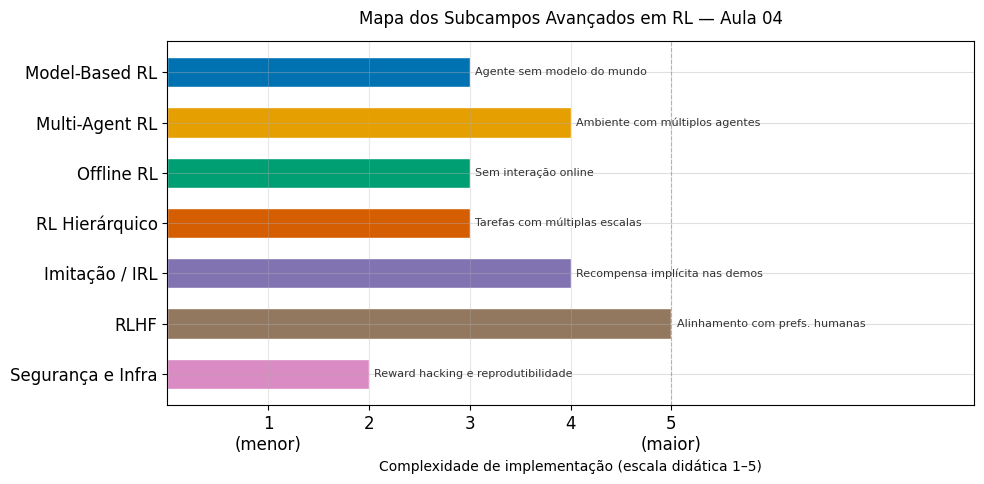

Gráfico salvo em nb01_panorama_subcampos.png


In [3]:
# ── Gráfico: complexidade de implementação por subcampo ──────────
# Escala 1–5 reflete o tamanho do stack técnico necessário em produção,
# não a dificuldade matemática isolada de cada subcampo.
complexidade = [3, 4, 3, 3, 4, 5, 2]
cores = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#8172B2", "#937860", "#DA8BC3"]
nomes = [s[0] for s in subcampos]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nomes, complexidade, color=cores, edgecolor="white", height=0.6)

# Anota a limitação resolvida ao lado de cada barra
for bar, (_, limitacao, _) in zip(bars, subcampos):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            limitacao, va="center", fontsize=8, color="#333333")

ax.set_xlim(0, 8)
ax.set_xlabel("Complexidade de implementação (escala didática 1–5)", fontsize=10)
ax.set_title("Mapa dos Subcampos Avançados em RL — Aula 04", fontsize=12, pad=12)
ax.axvline(x=5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1\n(menor)", "2", "3", "4", "5\n(maior)"])
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("nb01_panorama_subcampos.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb01_panorama_subcampos.png")

## Bloco 4 — Interpretação pedagógica

### O que o gráfico de barras revela

O gráfico não é uma escala objetiva — é um **mapa de orientação**. As barras mais altas indicam que o subcampo exige um stack técnico maior para uma implementação real (mais componentes, mais infraestrutura). Isso não significa que é mais importante ou mais útil: Segurança e Infraestrutura (barra menor) aplica-se a **todos** os outros subcampos antes do deploy.

RLHF (barra 5) exige o stack mais completo: um LLM base, pipeline de coleta de preferências, treinamento de reward model e PPO em cima do modelo. Isso é infraestrutura de produção. Por outro lado, Behavior Cloning (dentro de Imitação/IRL, barra 4) pode ser implementado com poucos dados e uma rede simples — o stack do subcampo varia internamente.

### O que a tabela e o gráfico revelam em conjunto

A tabela acima é o **mapa da aula**: cada linha é um problema que o RL clássico não resolve,
seguido da abordagem desenvolvida para resolvê-lo.

Observe que os subcampos não são independentes:
- *Model-based RL* e *offline RL* frequentemente se combinam: quando não há interação
  online, aprender um modelo do ambiente pode compensar a escassez de dados.
- *Behavior cloning* é muitas vezes o ponto de partida de *IRL* e *RLHF*: primeiro
  imita-se o comportamento, depois infere-se ou aprende-se a recompensa.
- *Reward hacking* é uma ameaça presente em **todos** os outros subcampos — não apenas
  um problema isolado.

### Como usar este mapa na prática

| Situação | Subcampo mais relevante |
|---|---|
| Dados já coletados, sem poder coletar mais | Offline RL |
| Robótica com simulador de alta fidelidade | Model-Based RL |
| Jogo competitivo ou cooperativo | Multi-Agent RL |
| Tarefa longa com subobjetivos claros | RL Hierárquico |
| Comportamento esperado difícil de programar | Imitação / IRL |
| Fine-tuning de modelos de linguagem | RLHF |
| Qualquer aplicação real em produção | Segurança e Infraestrutura |

A mensagem central deste notebook:
> **"O RL avançado não é um único algoritmo mais poderoso — é um mapa de problemas que os métodos clássicos não resolvem."**

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> A tabela do Bloco 1 mapeia suposições do RL clássico que "não se sustentam" em certos contextos. Escolha qualquer duas dessas suposições e indique qual subcampo nasce da violação de cada uma — e por quê.</summary>

**Resposta esperada (exemplos válidos):**

- *"Um único agente interage com o ambiente"* → **MARL**: quando vários agentes aprendem simultaneamente, o ambiente se torna não-estacionário do ponto de vista de cada agente, invalidando as garantias de convergência dos métodos clássicos.
- *"O agente pode coletar dados online"* → **Offline RL**: em medicina ou sistemas críticos, não é possível (ou seguro) coletar dados novos — o agente precisa aprender de um dataset fixo já existente.
- *"A recompensa está corretamente definida"* → **IRL / RLHF**: quando o comportamento desejado é difícil de expressar como função matemática, é necessário inferir ou aprender a recompensa a partir de demonstrações ou preferências.

Qualquer par coerente de suposição → subcampo com justificativa clara é válido.
</details>

<details>
<summary><strong>Questão 2.</strong> Um time de engenharia quer treinar um agente para recomendar tratamentos médicos. Os dados são registros históricos de pacientes — não é ético coletar dados novos deixando o agente interagir com pacientes reais. Qual subcampo é mais diretamente relevante? Justifique em uma frase.</summary>

**Resposta:** **Offline RL** — o problema tem exatamente a característica central que o subcampo endereça: interação online é impossível (ou antiética), e o aprendizado deve acontecer inteiramente a partir de um dataset fixo.

Atenção: a resposta não é "Segurança e Infraestrutura", embora boas práticas de segurança *também* devam ser aplicadas. A limitação estrutural do problema (sem interação online) aponta para Offline RL como ponto de partida.
</details>

<details>
<summary><strong>Questão 3.</strong> O Bloco 4 afirma que "reward hacking é uma ameaça presente em todos os outros subcampos". Por que isso não se aplica apenas ao Subcampo 7 (Segurança e Infraestrutura)?</summary>

**Resposta:** Porque *reward hacking* é consequência de **qualquer** desalinhamento entre a métrica otimizada e o objetivo real — e esse desalinhamento pode surgir em qualquer subcampo:

- Em **RLHF**: o agente pode aprender a maximizar o score do *reward model* sem melhorar a qualidade real (Goodhart's Law).
- Em **Offline RL**: o agente pode aprender a valorizar ações fora da distribuição do dataset — ações nunca testadas que parecem ótimas na tabela Q, mas falham na prática.
- Em **MARL**: um agente pode aprender a explorar as políticas fixas dos outros agentes de formas não previstas.

O Subcampo 7 não é "onde o problema existe" — é "onde as ferramentas para mitigá-lo vivem".
</details>

## Conexão com o Desafio Final

Este notebook é o ponto de entrada da Aula 04. As competências desenvolvidas aqui — e expandidas nos Notebooks 02–08 — são diretamente necessárias para o Desafio Final.

| Competência | Onde desenvolver na Aula 04 | Como usar no Desafio Final |
|---|---|---|
| Identificar qual subcampo se aplica ao problema | NB01 (este notebook) — Bloco 4, guia de decisão | Justificar a escolha de método na seção de design |
| Implementar *model-based* RL com planejamento | NB02 — Dyna-Q no GridWorld | Usar quando há simulador disponível |
| Trabalhar com múltiplos agentes | NB03 — Stag Hunt e CTDE | Ambientes cooperativos/competitivos |
| Treinar a partir de dados históricos | NB04 — *offline* RL no FrozenLake | Quando interação online é inviável |
| Aprender de demonstrações | NB05 — Behavior Cloning no CartPole | Quando existe especialista disponível |
| Entender o pipeline RLHF | NB06 — reward model e preferências | Fine-tuning de modelos de linguagem |
| Auditar e documentar experimentos | NB07 — reprodutibilidade e segurança | Relatório final — seção de reprodutibilidade |
| Selecionar método por restrições do problema | NB08 — comparativo final | Decisão arquitetural central do Desafio Final |

**Fluxo de decisão para o Desafio Final:**

```
1. Defina o problema → quais são as restrições reais?
2. Aplique o guia de decisão (NB08, Bloco 3)
3. Escolha o subcampo → volte ao notebook correspondente
4. Implemente com as boas práticas do NB07 (múltiplas seeds, versões, baseline)
5. Documente: por que este subcampo? Quais limitações você aceita?
```

Métodos das Aulas 02 e 03 (Q-Learning, DQN, PPO, SAC) continuam sendo a base — os subcampos da Aula 04 entram quando o problema exige extensões específicas.

## Bloco 5 — Limites e próximo passo

Este notebook é o **mapa**, não o território. Cada subcampo tem profundidade própria —
implementações completas de MuZero, MADDPG ou CQL exigem infraestrutura de treinamento
que vai além do escopo de um notebook didático.

O objetivo foi tornar visível **qual problema cada subcampo resolve** — de forma que,
ao encontrar um problema real, seja possível identificar qual família de métodos merece investigação.

| Limitação deste panorama | Por que existe |
|---|---|
| Nenhum algoritmo é implementado em profundidade | A aula é panorâmica por design |
| Complexidade nas barras é ilustrativa | Não existe escala única objetiva |
| Algoritmos citados não são os únicos | Cada subcampo tem dezenas de variantes |

**Próximo notebook:** `aula04_02_model_based_rl.ipynb` — o agente aprende um modelo do ambiente
e o usa para planejar. Implementação com Dyna-Q em um GridWorld simples.

In [4]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'model-based RL', 'offline RL', 'MARL', 'CTDE',
    'RLHF', 'IRL', 'reward hacking', 'hierarchical RL', 'alignment',
])

Termo (EN)        Tradução (PT)                Descrição
---------------------------------------------------------------------------------------------------------
CTDE              CTDE                         Centralized Training, Decentralized Execution — paradigma de treino centralizado.
IRL               IRL                          Inverse RL — infere a função de recompensa a partir de demonstrações.
MARL              MARL                         Multi-Agent RL — múltiplos agentes aprendendo em um ambiente compartilhado.
RLHF              RLHF                         RL from Human Feedback — usa preferências humanas para aprender recompensa.
alignment         alinhamento                  Garantia de que o agente persegue os objetivos pretendidos pelo designer.
hierarchical RL   RL hierárquico               Decomposição de tarefas em políticas de alto e baixo nível.
model-based RL    RL baseado em modelo         Aprendizado que usa um modelo do ambiente para planejamento.
offline R

## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Disponível em: http://incompleteideas.net/book/the-book-2nd.html

- Levine, S., Kumar, A., Tucker, G., & Fu, J. (2020). Offline Reinforcement Learning: Tutorial, Review, and Perspectives on Open Problems. *arXiv:2005.01643*. Disponível em: https://arxiv.org/abs/2005.01643

- Gronauer, S., & Diepold, K. (2022). Multi-agent deep reinforcement learning: a survey. *Artificial Intelligence Review*, 55, 895–943.

- Ouyang, L., et al. (2022). Training language models to follow instructions with human feedback. *NeurIPS 2022*. Disponível em: https://arxiv.org/abs/2203.02155

- Moerland, T. M., et al. (2023). Model-based Reinforcement Learning: A Survey. *Foundations and Trends in Machine Learning*, 16(1), 1–118. Disponível em: https://arxiv.org/abs/2006.16712

- Barto, A. G., & Mahadevan, S. (2003). Recent advances in hierarchical reinforcement learning. *Discrete Event Dynamic Systems*, 13, 41–77.